# Transaction CSV Completeness Check

This notebook checks completeness for all columns in `transaction.csv`.

Outputs include:
- Missing count per column
- Missing percentage per column
- Complete count per column
- Complete percentage per column
- Overall dataset completeness

In [1]:
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

df = pd.read_csv("transaction.csv")
print(f"Loaded dataframe shape: {df.shape}")
df.head()

Loaded dataframe shape: (10103, 6)


,status,time,card_type,city,amount,id
0,success,23:17 2025-09-08,Discover,ThRan,-5000,1
1,failed,NaN,MastCard,karaj,63489,2
2,success,07:32 2025-09-20,Visa,Isfahan,1502601,3
3,failed,03-00-2025 09-11,Discover,Qom,9999999999,4
4,success,22:27 2025-09-11,Amex,Mashhad,452545,5


## Column-Level Completeness

In [2]:
total_rows = len(df)

missing_count = df.isna().sum()
missing_pct = (missing_count / total_rows * 100).round(2)
complete_count = total_rows - missing_count
complete_pct = (complete_count / total_rows * 100).round(2)

completeness_table = pd.DataFrame({
    "column": df.columns,
    "total_rows": total_rows,
    "missing_count": missing_count.values,
    "missing_pct": missing_pct.values,
    "complete_count": complete_count.values,
    "complete_pct": complete_pct.values,
}).sort_values(by=["missing_count", "column"], ascending=[False, True]).reset_index(drop=True)

display(completeness_table)

,column,total_rows,missing_count,missing_pct,complete_count,complete_pct
0,card_type,10103,314,3.11,9789,96.89
1,city,10103,117,1.16,9986,98.84
2,time,10103,8,0.08,10095,99.92
3,amount,10103,2,0.02,10101,99.98
4,id,10103,0,0.00,10103,100.00
5,status,10103,0,0.00,10103,100.00


## Overall Completeness

In [3]:
total_cells = df.shape[0] * df.shape[1]
missing_cells = int(df.isna().sum().sum())
complete_cells = total_cells - missing_cells

overall_table = pd.DataFrame([
    {
        "total_rows": df.shape[0],
        "total_columns": df.shape[1],
        "total_cells": total_cells,
        "missing_cells": missing_cells,
        "missing_pct": round(missing_cells / total_cells * 100, 2),
        "complete_cells": complete_cells,
        "complete_pct": round(complete_cells / total_cells * 100, 2),
    }
])

display(overall_table)

,total_rows,total_columns,total_cells,missing_cells,missing_pct,complete_cells,complete_pct
0,10103,6,60618,441,0.73,60177,99.27


## Completeness Visualizations

Bar chart shows missing percentage by column. Heatmap shows missing-value pattern across rows/columns (`1 = missing`, `0 = present`).

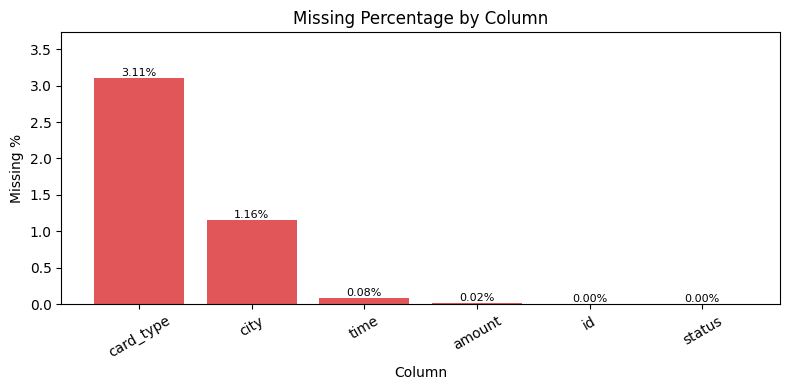

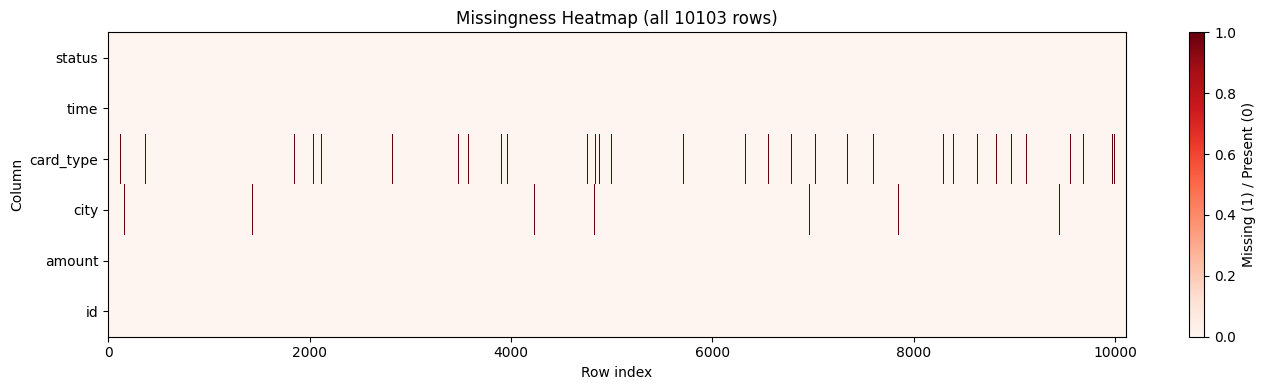

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# ---------- Bar chart: missing % by column ----------
bar_df = completeness_table.sort_values("missing_pct", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(bar_df["column"], bar_df["missing_pct"], color="#e15759")
ax.set_title("Missing Percentage by Column")
ax.set_ylabel("Missing %")
ax.set_xlabel("Column")
ax.set_ylim(0, max(1, float(bar_df["missing_pct"].max()) * 1.2))
ax.tick_params(axis="x", rotation=30)

for bar, v in zip(bars, bar_df["missing_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{v:.2f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# ---------- Heatmap: missingness pattern (all rows) ----------
N = len(df)
missing_matrix = df.isna().astype(int).T.values  # shape: columns x rows

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(missing_matrix, aspect="auto", cmap="Reds", interpolation="nearest")

ax.set_title(f"Missingness Heatmap (all {N} rows)")
ax.set_xlabel("Row index")
ax.set_ylabel("Column")
ax.set_yticks(np.arange(len(df.columns)))
ax.set_yticklabels(df.columns)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Missing (1) / Present (0)")

plt.tight_layout()
plt.show()

## Additional Completeness Charts

- Stacked bar: complete vs missing count per column
- Pie: overall complete vs missing cells
- Before/after comparison after treatment

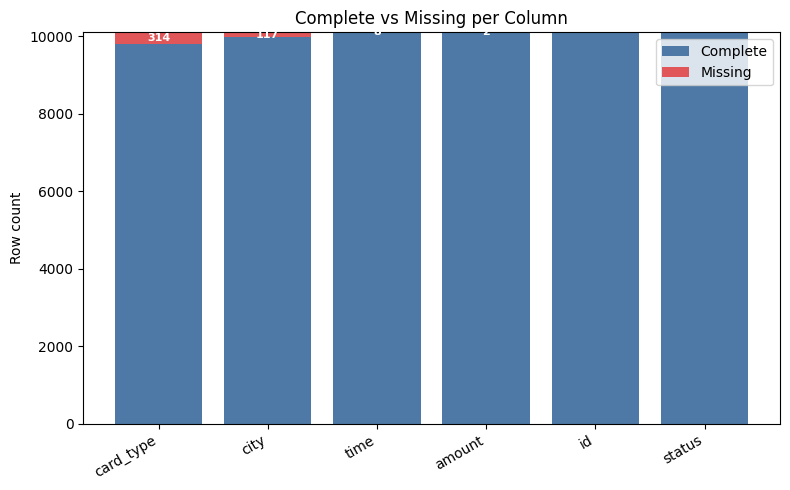

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# ── Stacked bar: complete vs missing count per column ──
cols = completeness_table["column"]
complete = completeness_table["complete_count"]
missing = completeness_table["missing_count"]
x = np.arange(len(cols))

fig, ax = plt.subplots(figsize=(8, 5))
bars_c = ax.bar(x, complete, color="#4e79a7", label="Complete")
bars_m = ax.bar(x, missing, bottom=complete, color="#e15759", label="Missing")
ax.set_title("Complete vs Missing per Column")
ax.set_xticks(x)
ax.set_xticklabels(cols, rotation=30, ha="right")
ax.set_ylabel("Row count")
ax.legend()

for bar, m in zip(bars_m, missing):
    if m > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_y() + bar.get_height() / 2,
            str(int(m)), ha="center", va="center", fontsize=8, color="white", fontweight="bold"
        )

plt.tight_layout()
plt.show()

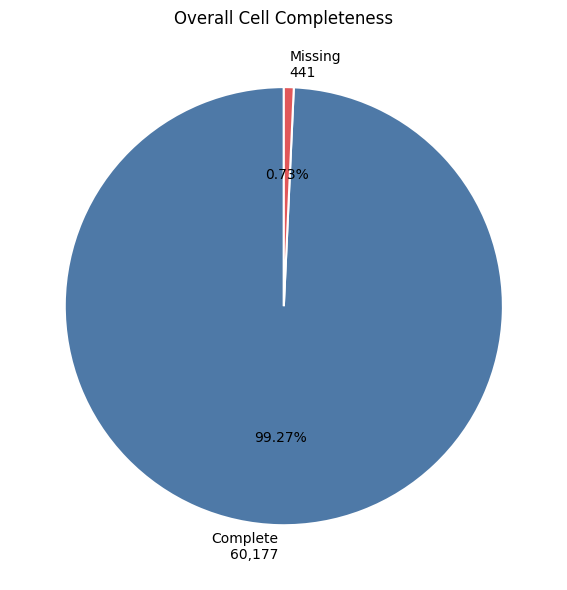

In [6]:
# ── Pie: overall complete vs missing cells ──
total_cells = df.shape[0] * df.shape[1]
missing_cells = int(df.isna().sum().sum())
complete_cells = total_cells - missing_cells

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    [complete_cells, missing_cells],
    labels=[f"Complete\n{complete_cells:,}", f"Missing\n{missing_cells:,}"],
    colors=["#4e79a7", "#e15759"],
    autopct="%1.2f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
ax.set_title("Overall Cell Completeness")
plt.tight_layout()
plt.show()

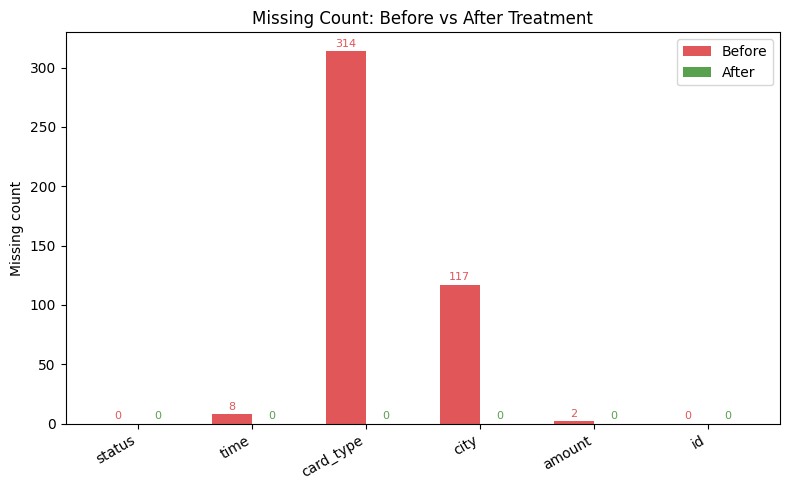

In [7]:
# ── Grouped bar: missing count before vs after treatment ──
df_clean_temp = df.copy()
df_clean_temp = df_clean_temp.dropna(subset=["amount", "time"])
df_clean_temp["card_type"] = df_clean_temp["card_type"].fillna("Unknown")
df_clean_temp["city"] = df_clean_temp["city"].fillna("Unknown")

before = df.isna().sum()
after = df_clean_temp.isna().sum()
cols_all = df.columns.tolist()
x = np.arange(len(cols_all))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_b = ax.bar(x - width/2, before[cols_all], width, color="#e15759", label="Before")
bars_a = ax.bar(x + width/2, after[cols_all], width, color="#59a14f", label="After")

# Label before bars
for bar, val in zip(bars_b, before[cols_all]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(int(val)), ha="center", va="bottom", fontsize=8, color="#e15759"
    )

# Label after bars (show 0 even when bar invisible)
for bar, val in zip(bars_a, after[cols_all]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(int(val)), ha="center", va="bottom", fontsize=8, color="#59a14f"
    )

ax.set_title("Missing Count: Before vs After Treatment")
ax.set_xticks(x)
ax.set_xticklabels(cols_all, rotation=30, ha="right")
ax.set_ylabel("Missing count")
ax.legend()
plt.tight_layout()
plt.show()

## Missing Value Treatment

- `amount`, `time`: drop rows — critical fields, cannot impute
- `card_type`, `city`: fill with `"Unknown"` — categorical, 3.11% / 1.16% missing

In [8]:
df_clean = df.copy()

# Drop rows where critical fields missing
rows_before = len(df_clean)
df_clean = df_clean.dropna(subset=["amount", "time"])
dropped = rows_before - len(df_clean)
print(f"Dropped {dropped} rows (missing amount or time)")

# Fill categorical missing with "Unknown"
df_clean["card_type"] = df_clean["card_type"].fillna("Unknown")
df_clean["city"] = df_clean["city"].fillna("Unknown")
print(f"Filled card_type and city missing values with 'Unknown'")

# Verify
print(f"\nRemaining shape: {df_clean.shape}")
print(f"Missing after treatment:\n{df_clean.isna().sum()}")

Dropped 8 rows (missing amount or time)
Filled card_type and city missing values with 'Unknown'

Remaining shape: (10095, 6)
Missing after treatment:
status       0
time         0
card_type    0
city         0
amount       0
id           0
dtype: int64
